## Section 1 — Introduction

### CRISP-DM: Business Understanding

The goal of this project is to build machine learning models that can predict whether a patient is at risk of experiencing a stroke based on health and demographic features.

This notebook implements CRISP-DM steps:
- Business Understanding
- Data Understanding
- Data Preparation
- Modeling
- Evaluation
- Deployment & Interpretability (SHAP)

Models used:
- Logistic Regression
- Random Forest Classifier

## SECTION 2 — Import Libraries

In [1]:
# Important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score, roc_curve
)

# Interpretability
import shap

# Display settings
pd.set_option('display.max_columns', None)

In [2]:
# Visualization settings and figure directory
import os
import matplotlib as mpl

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['font.size'] = 5
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 5

DEFAULT_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
sns.set_theme(style="whitegrid", palette=DEFAULT_PALETTE)

## SECTION 3 — Load Stroke Dataset

Load the CSV file and display the first rows to understand the schema.

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")   # ensure the file path is correct
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## SECTION 4 — Data Inspection

Check dataset shape, types and a statistical summary.

In [4]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())

print("\nStatistical Description:")
df.describe(include='all')


Dataset Shape: (10220, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10220 entries, 0 to 10219
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10220 non-null  int64  
 1   gender             10220 non-null  object 
 2   age                10220 non-null  float64
 3   hypertension       10220 non-null  int64  
 4   heart_disease      10220 non-null  int64  
 5   ever_married       10220 non-null  object 
 6   work_type          10220 non-null  object 
 7   Residence_type     10220 non-null  object 
 8   avg_glucose_level  10220 non-null  float64
 9   bmi                9818 non-null   float64
 10  smoking_status     10220 non-null  object 
 11  stroke             10220 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 958.3+ KB
None

Statistical Description:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,10220.000000,10220,10220.000000,10220.000000,10220.000000,10220,10220,10220,10220.000000,9818.000000,10220,10220.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,5988,NaN,NaN,NaN,6706,5850,5192,NaN,NaN,3784,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21160.686189,NaN,22.611540,0.296592,0.226052,NaN,NaN,NaN,45.281344,7.853667,NaN,0.215309
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17740.000000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.240000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54695.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


## SECTION 5 — Missing Values

Identify missing values and their counts for later imputation.

In [5]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  402
smoking_status         0
stroke                 0
dtype: int64

## SECTION 6 — Exploratory Data Analysis (EDA)

We will visualize distribution of the target, numeric feature histograms, and numeric correlation heatmap.
All figures will be saved to the `figures/` folder for the report.


C:\Users\vatan\AppData\Local\Temp\ipykernel_39484\4058099659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette=[DEFAULT_PALETTE[0], DEFAULT_PALETTE[1]])


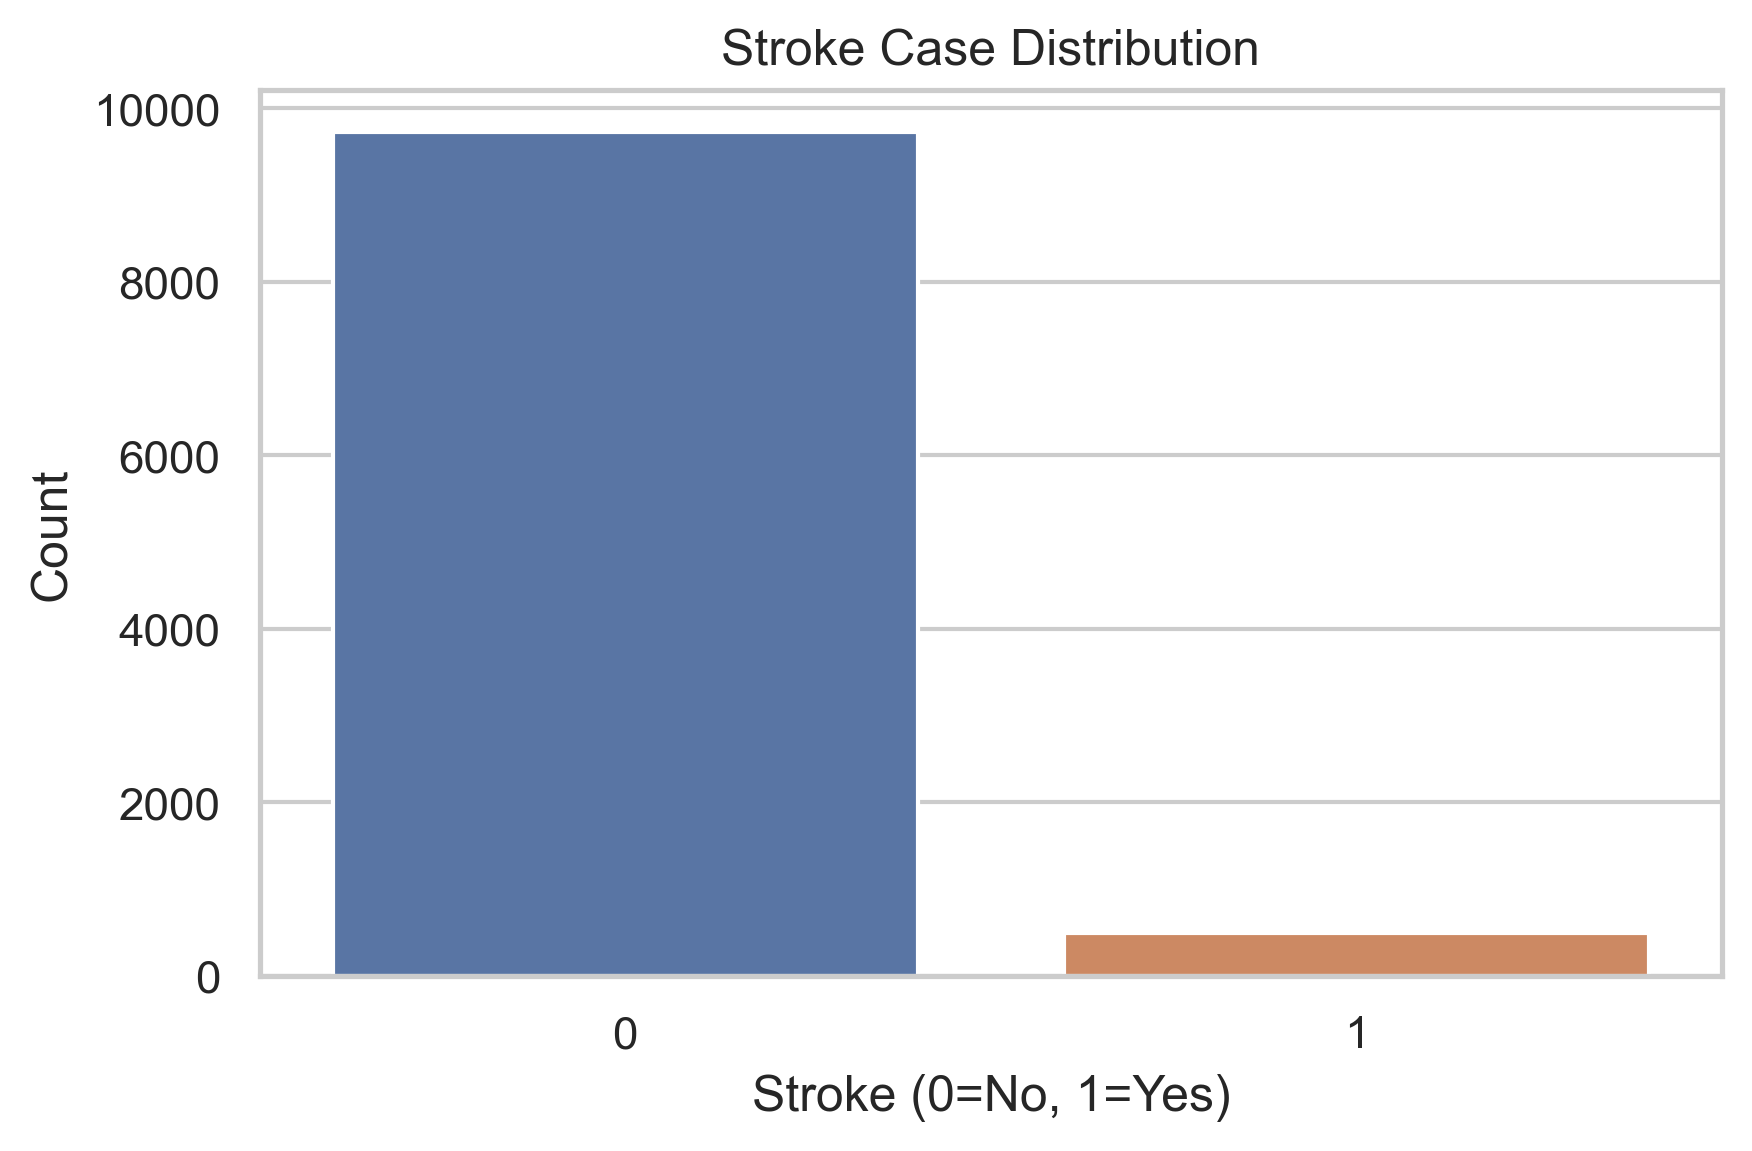

Percentage distribution:
 stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df, palette=[DEFAULT_PALETTE[0], DEFAULT_PALETTE[1]])
plt.title("Stroke Case Distribution")
plt.xlabel("Stroke (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/stroke_distribution.png")
plt.show()

print("Percentage distribution:\n", (df['stroke'].value_counts(normalize=True) * 100).round(2))

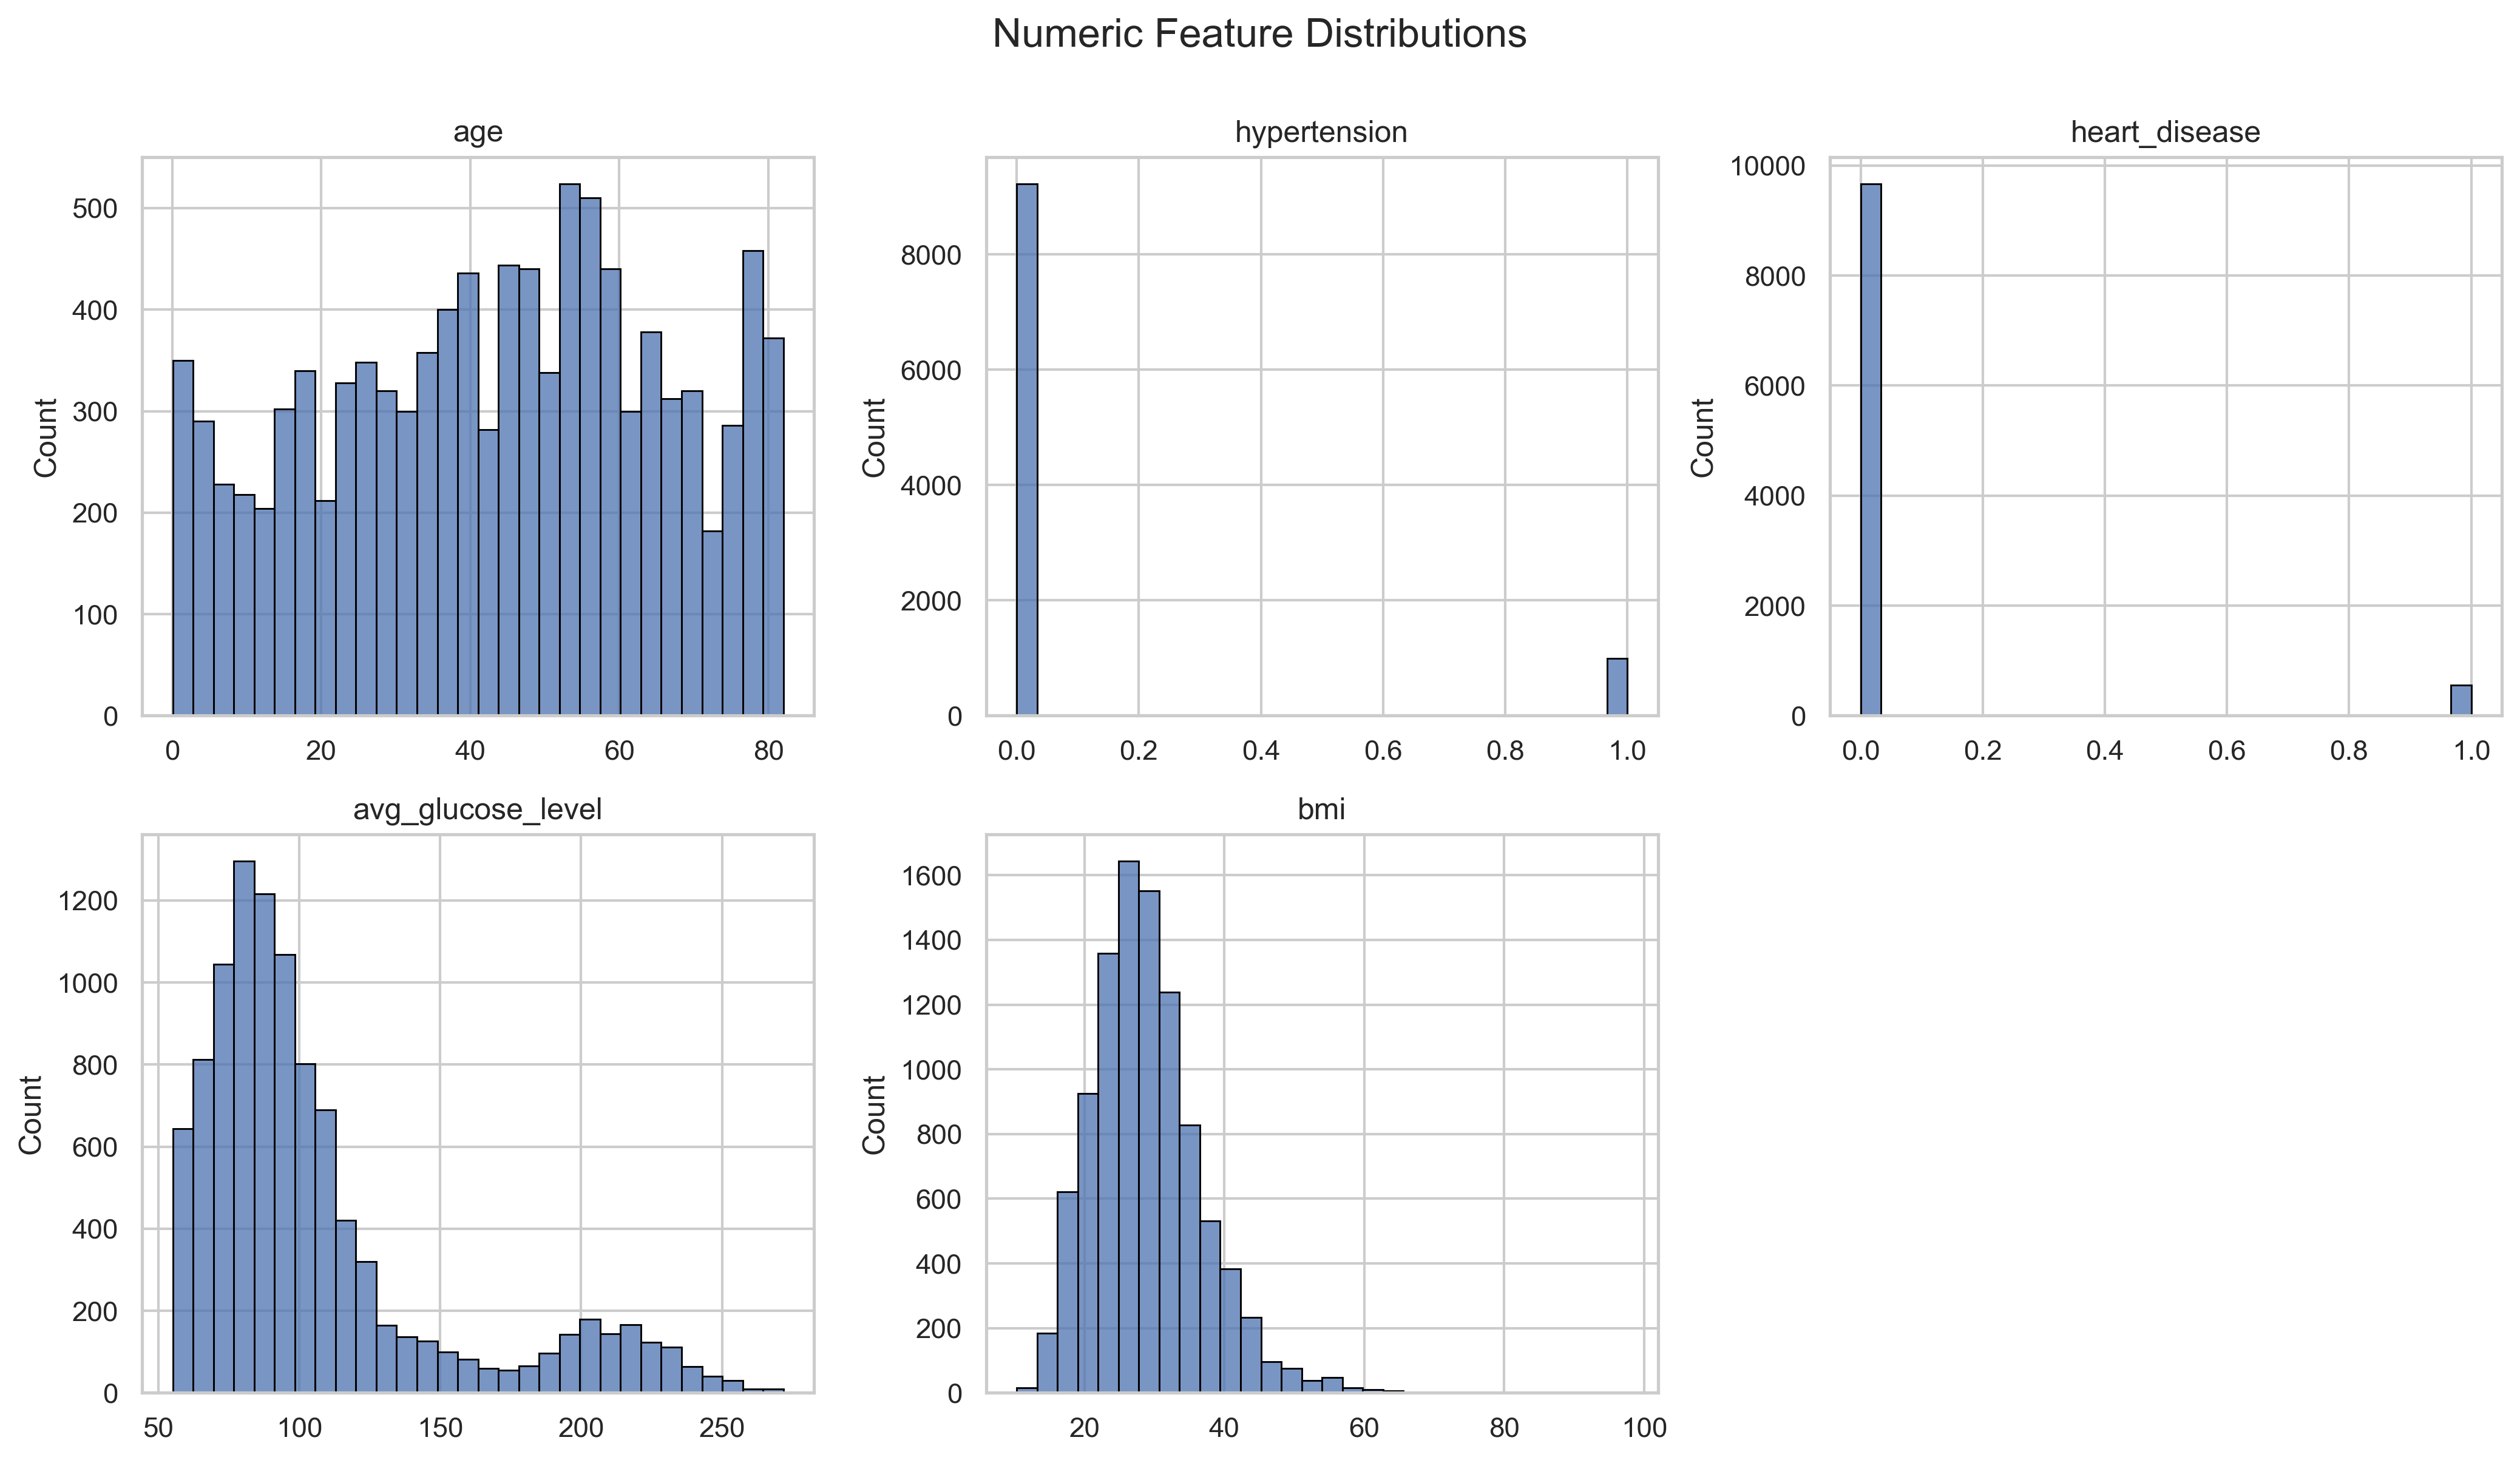

In [8]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in ['id','stroke']]
n = len(numeric_cols)

rows = int(np.ceil(n / 3))
fig, axes = plt.subplots(rows, 3, figsize=(14, 4*rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, color=DEFAULT_PALETTE[0], edgecolor='black', ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Numeric Feature Distributions", fontsize=16, y=1)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/numeric_feature_histograms.png")
plt.show()

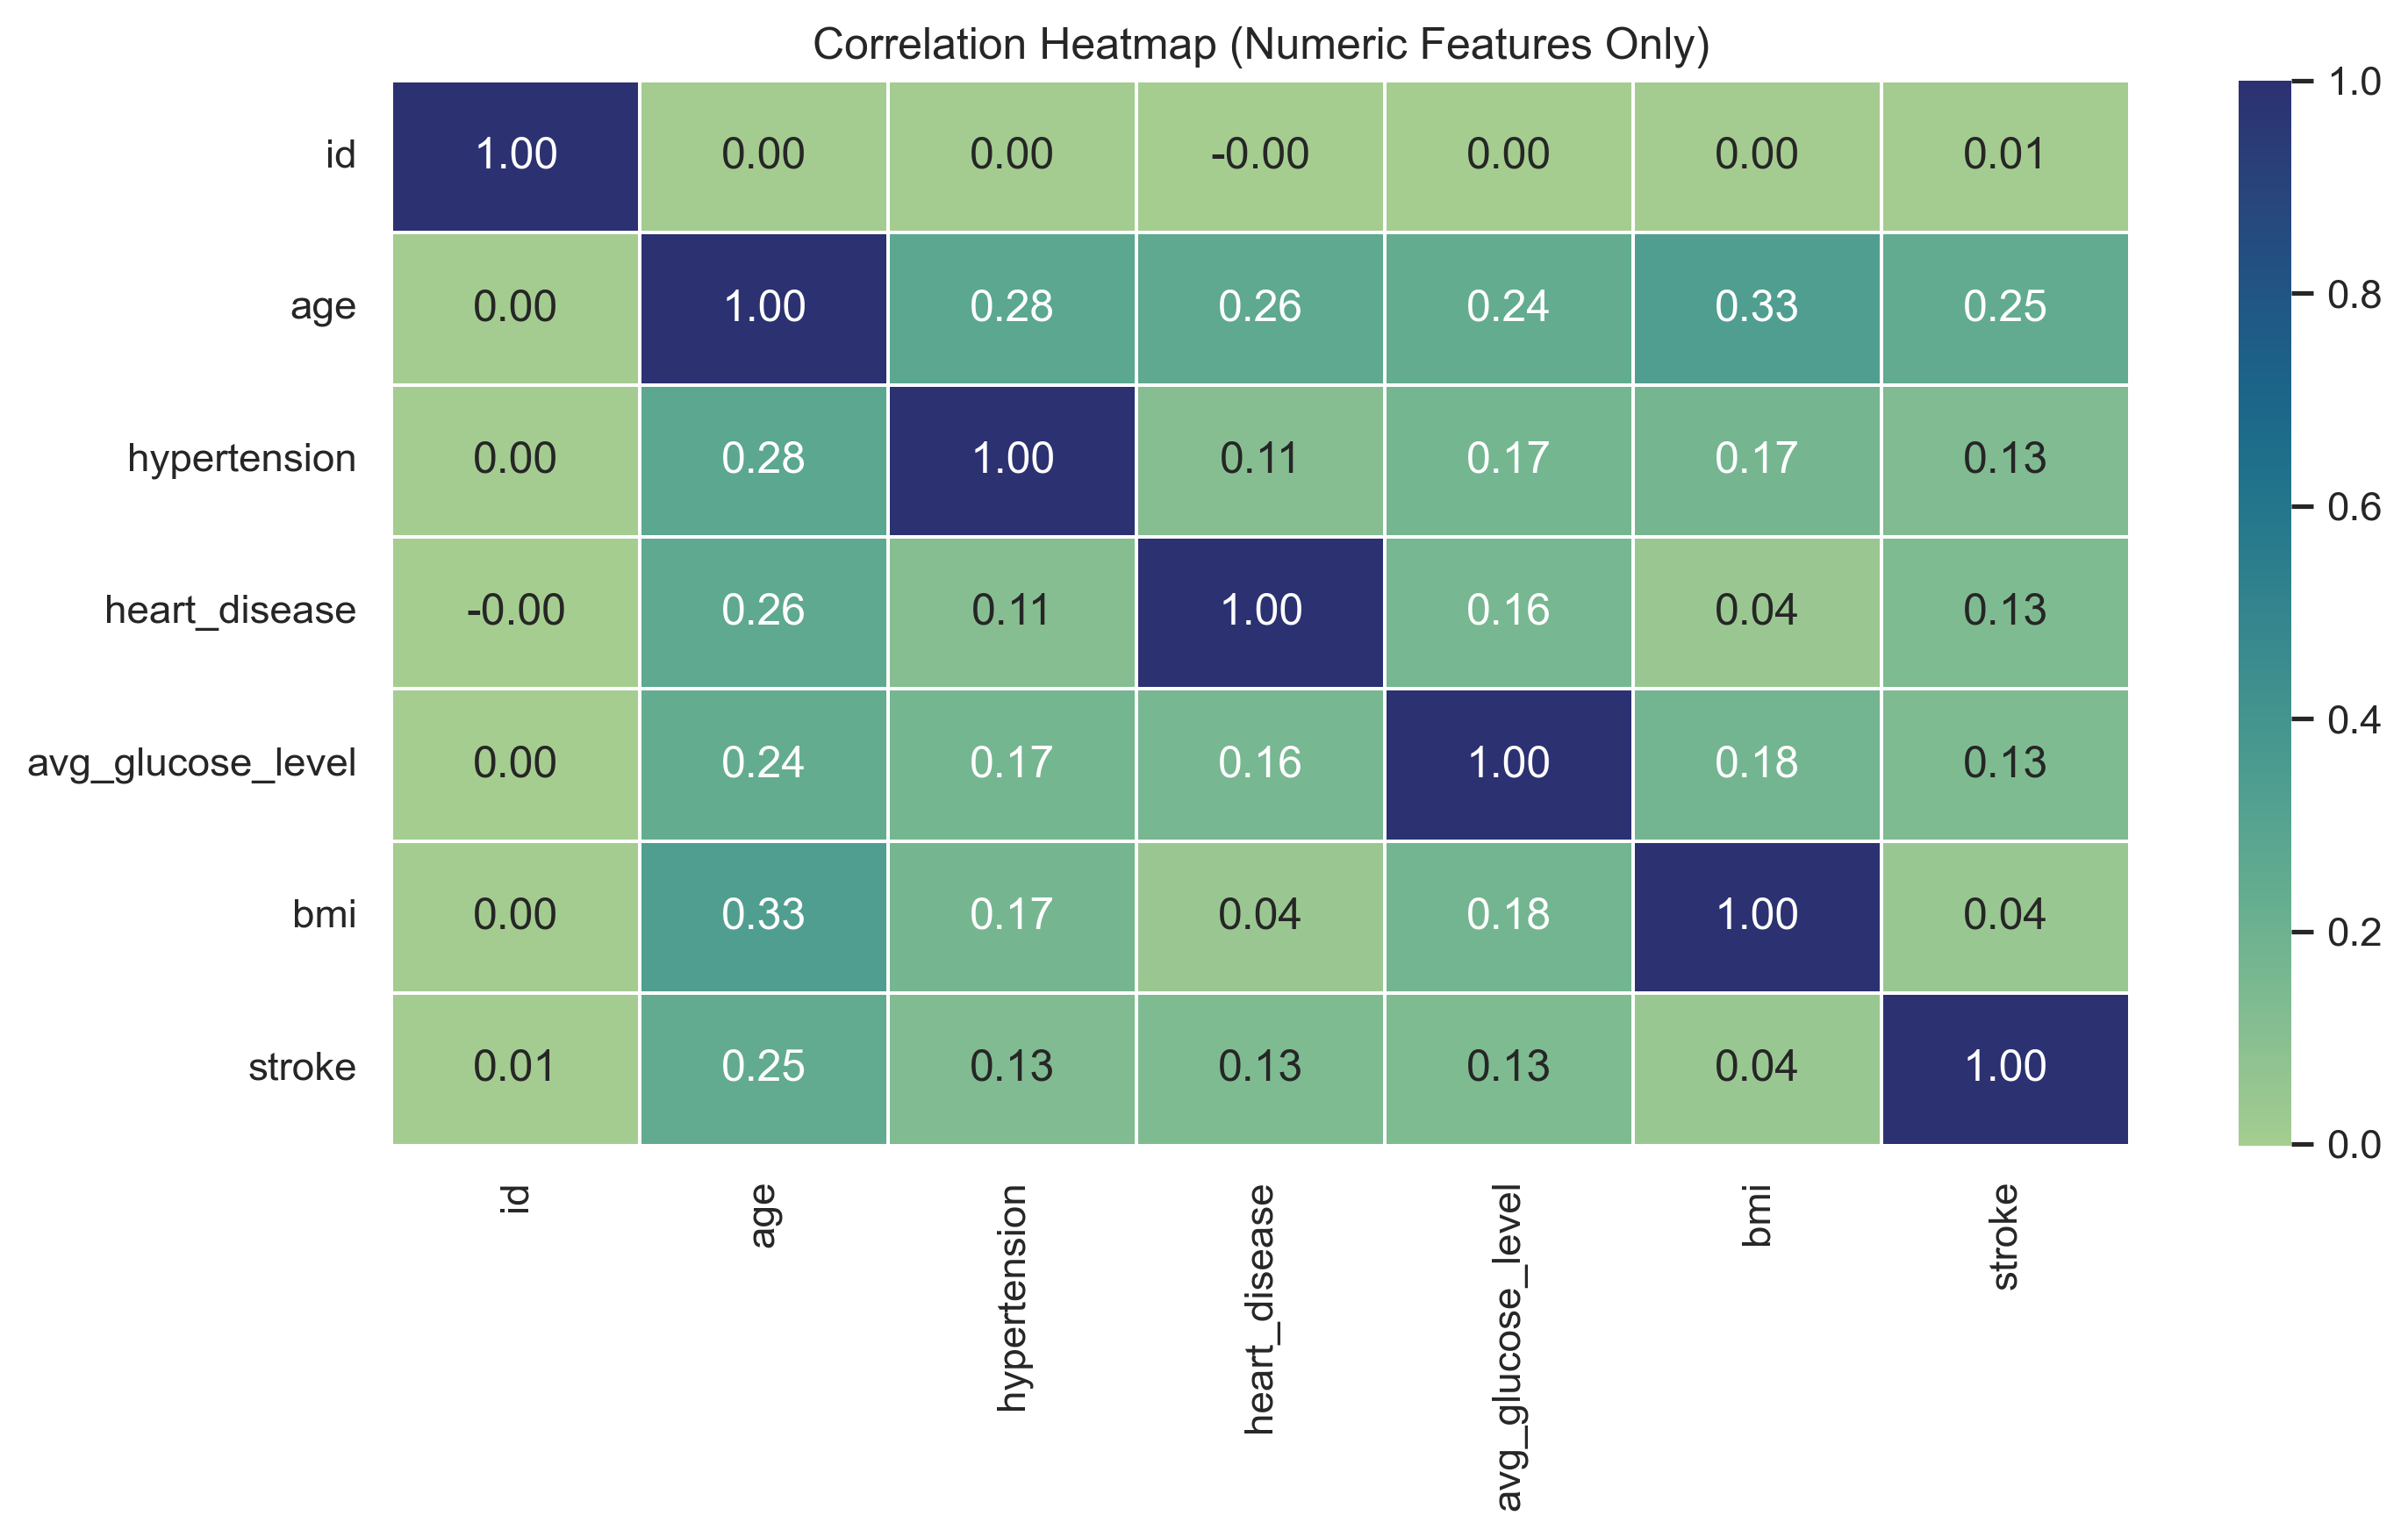

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="crest", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png")
plt.show()

## SECTION 7 — Data Preprocessing

Prepare the features and target variable. Identify categorical and numeric columns and define a ColumnTransformer
that will scale numeric features and one-hot encode categorical features.

In [10]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
numeric_cols = [c for c in X.columns if c not in categorical_cols + ["id"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## SECTION 8 — Train-Test Split

Split the data into training and test sets with stratification on the target to preserve class proportions.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((7665, 11), (2555, 11))

## SECTION 9 — Logistic Regression

Train a logistic regression model as a baseline with the preprocessing pipeline.

In [15]:
logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train
logreg_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logreg_model.predict(X_test)
y_prob_lr = logreg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


## SECTION 10 — Logistic Regression Evaluation

Report key classification metrics and save the confusion matrix figure.


Accuracy: 0.95146771037182
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC Score: 0.8510204217035336
Cohen Kappa: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98      2431
           1       0.00      0.00      0.00       124

    accuracy                           0.95      2555
   macro avg       0.48      0.50      0.49      2555
weighted avg       0.91      0.95      0.93      2555



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklea

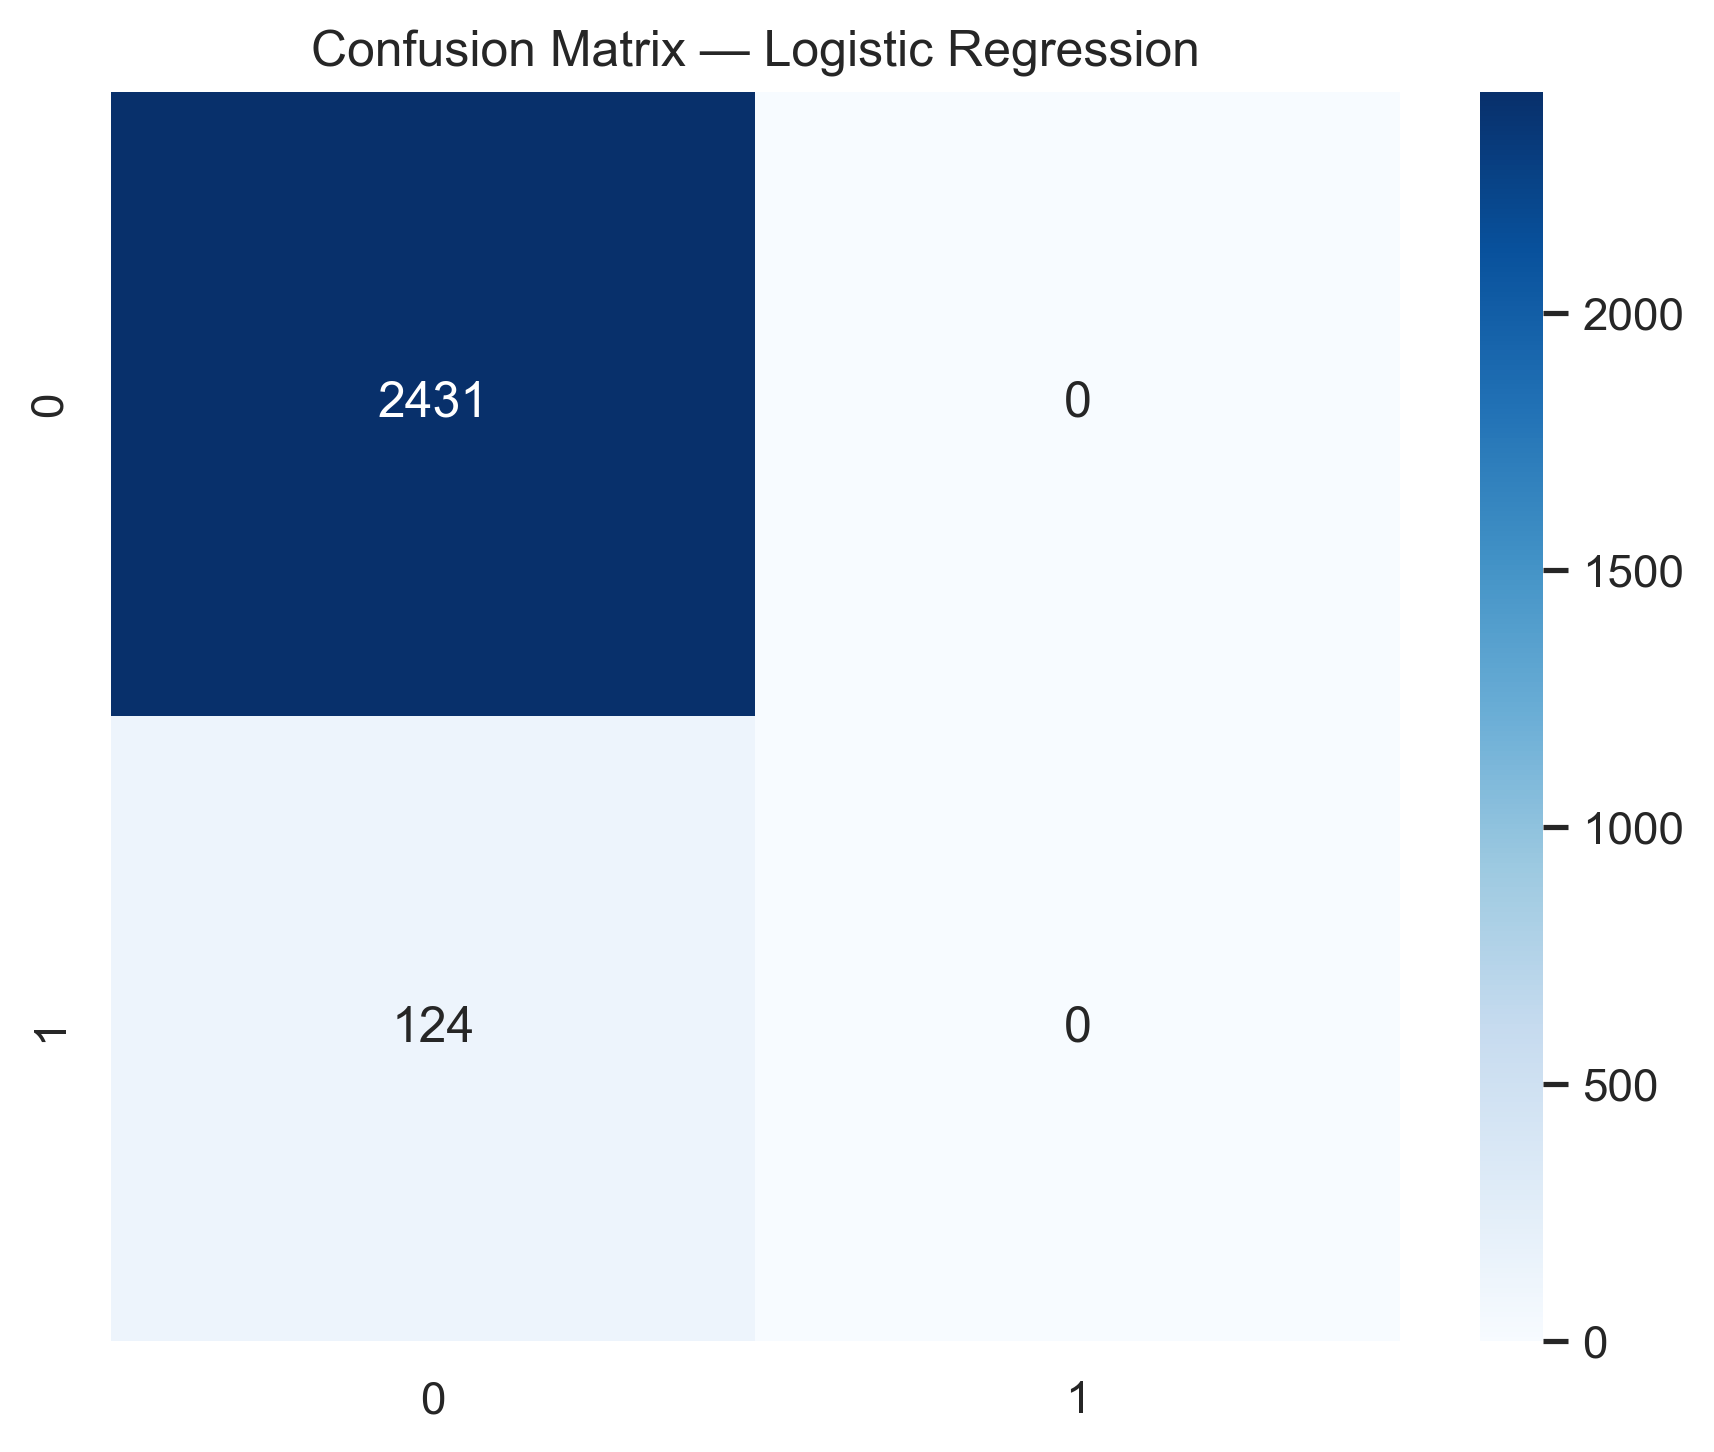

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("AUC Score:", roc_auc_score(y_test, y_prob_lr))
print("Cohen Kappa:", cohen_kappa_score(y_test, y_pred_lr))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cm_logistic_regression.png")
plt.show()

## SECTION 11 — Random Forest

Train a Random Forest classifier (tree ensemble) with balanced class weights to mitigate imbalance.

In [17]:
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

## SECTION 12 — Random Forest Evaluation

Report metrics and save the confusion matrix figure.


Accuracy: 0.9385518590998043
Precision: 0.4297872340425532
Recall: 0.8145161290322581
F1 Score: 0.5626740947075209
AUC Score: 0.9624474197529226
Cohen Kappa: 0.5330019267374108

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.97      2431
           1       0.43      0.81      0.56       124

    accuracy                           0.94      2555
   macro avg       0.71      0.88      0.76      2555
weighted avg       0.96      0.94      0.95      2555



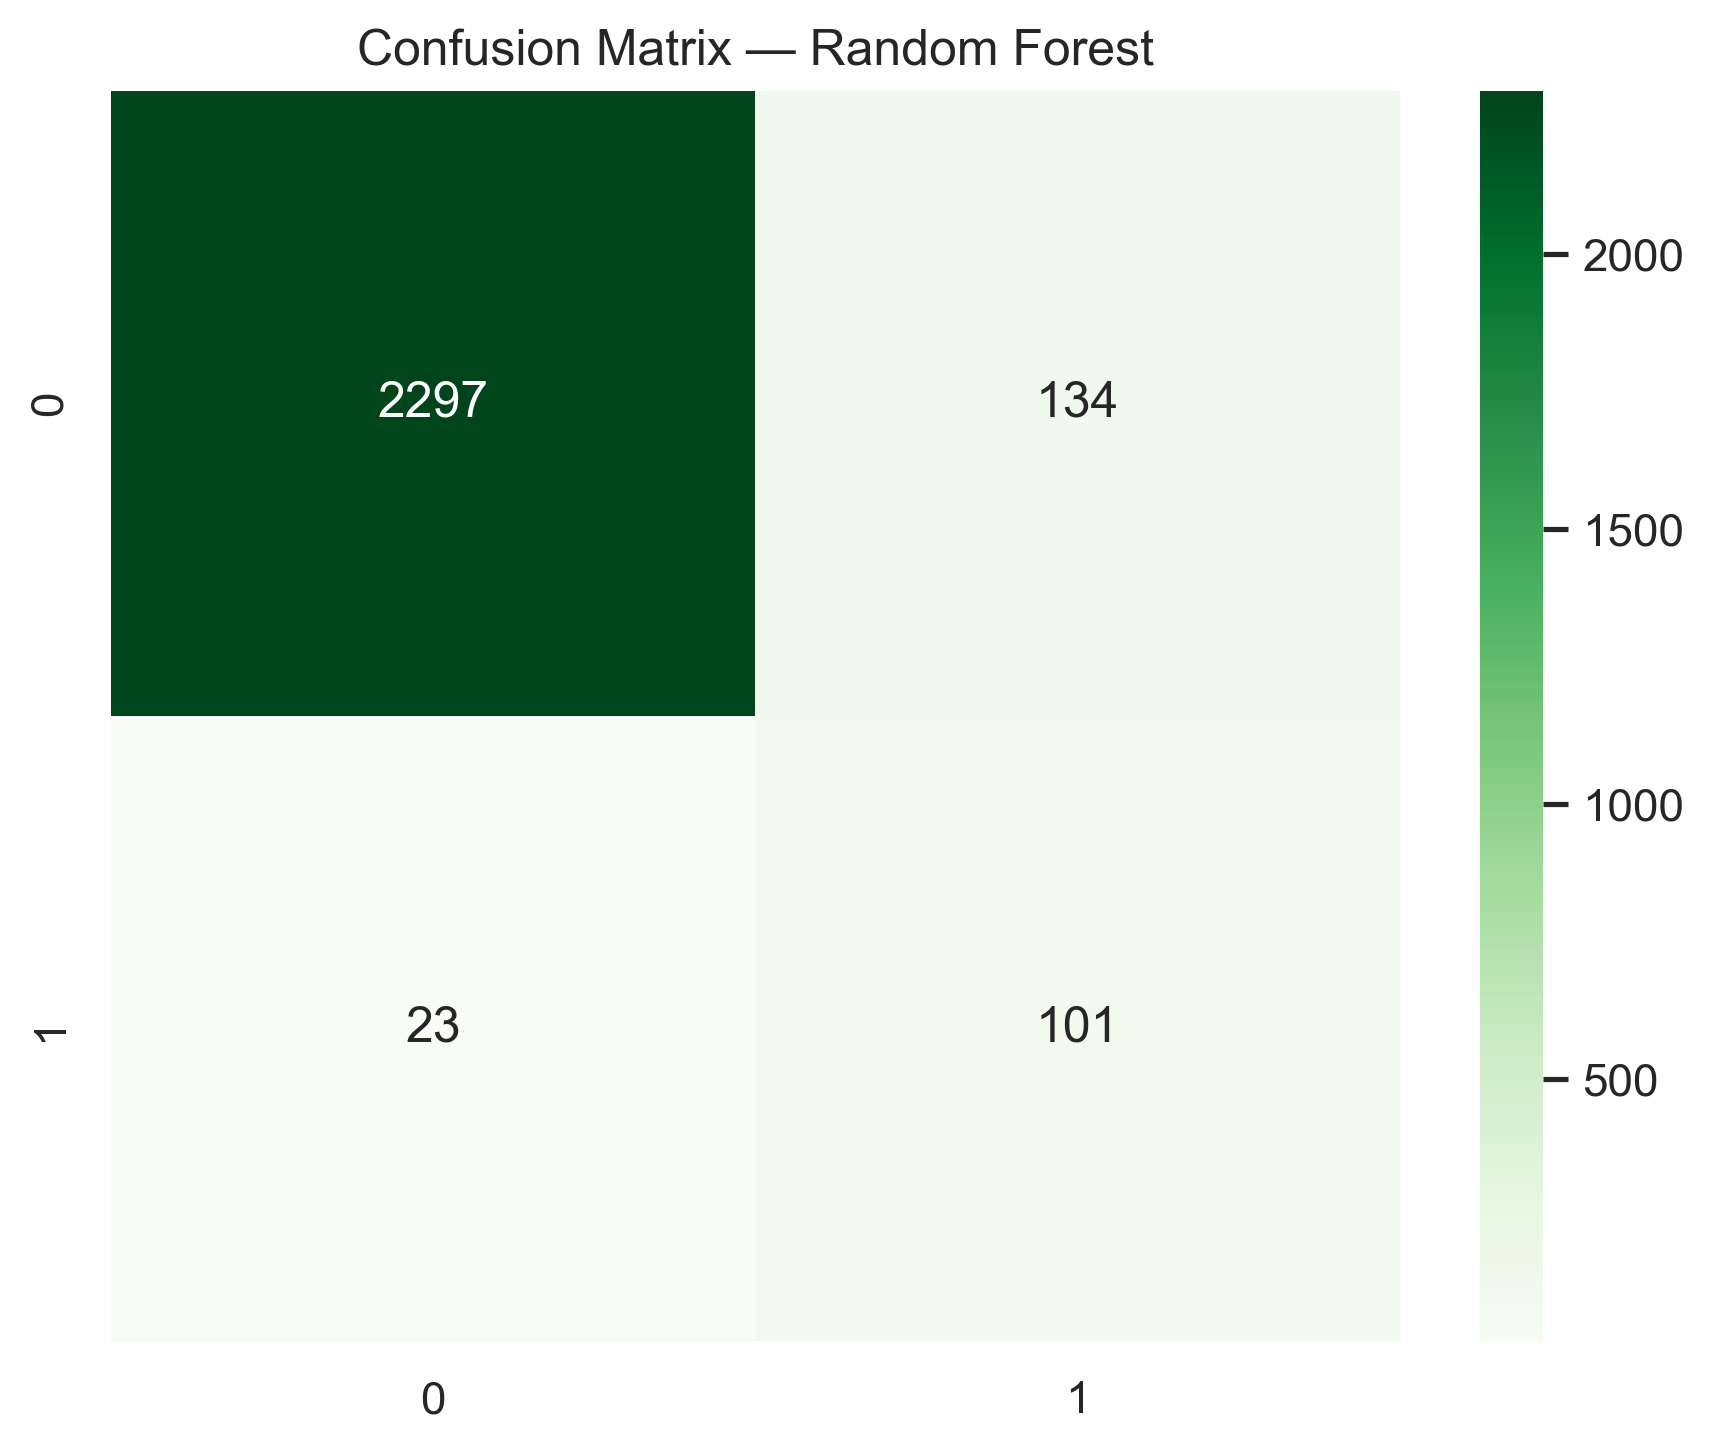

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("AUC Score:", roc_auc_score(y_test, y_prob_rf))
print("Cohen Kappa:", cohen_kappa_score(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, cmap="Greens", fmt="d")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cm_random_forest.png")
plt.show()

## SECTION 13 — ROC Curves

Plot ROC curves for both models and save to figures directory.


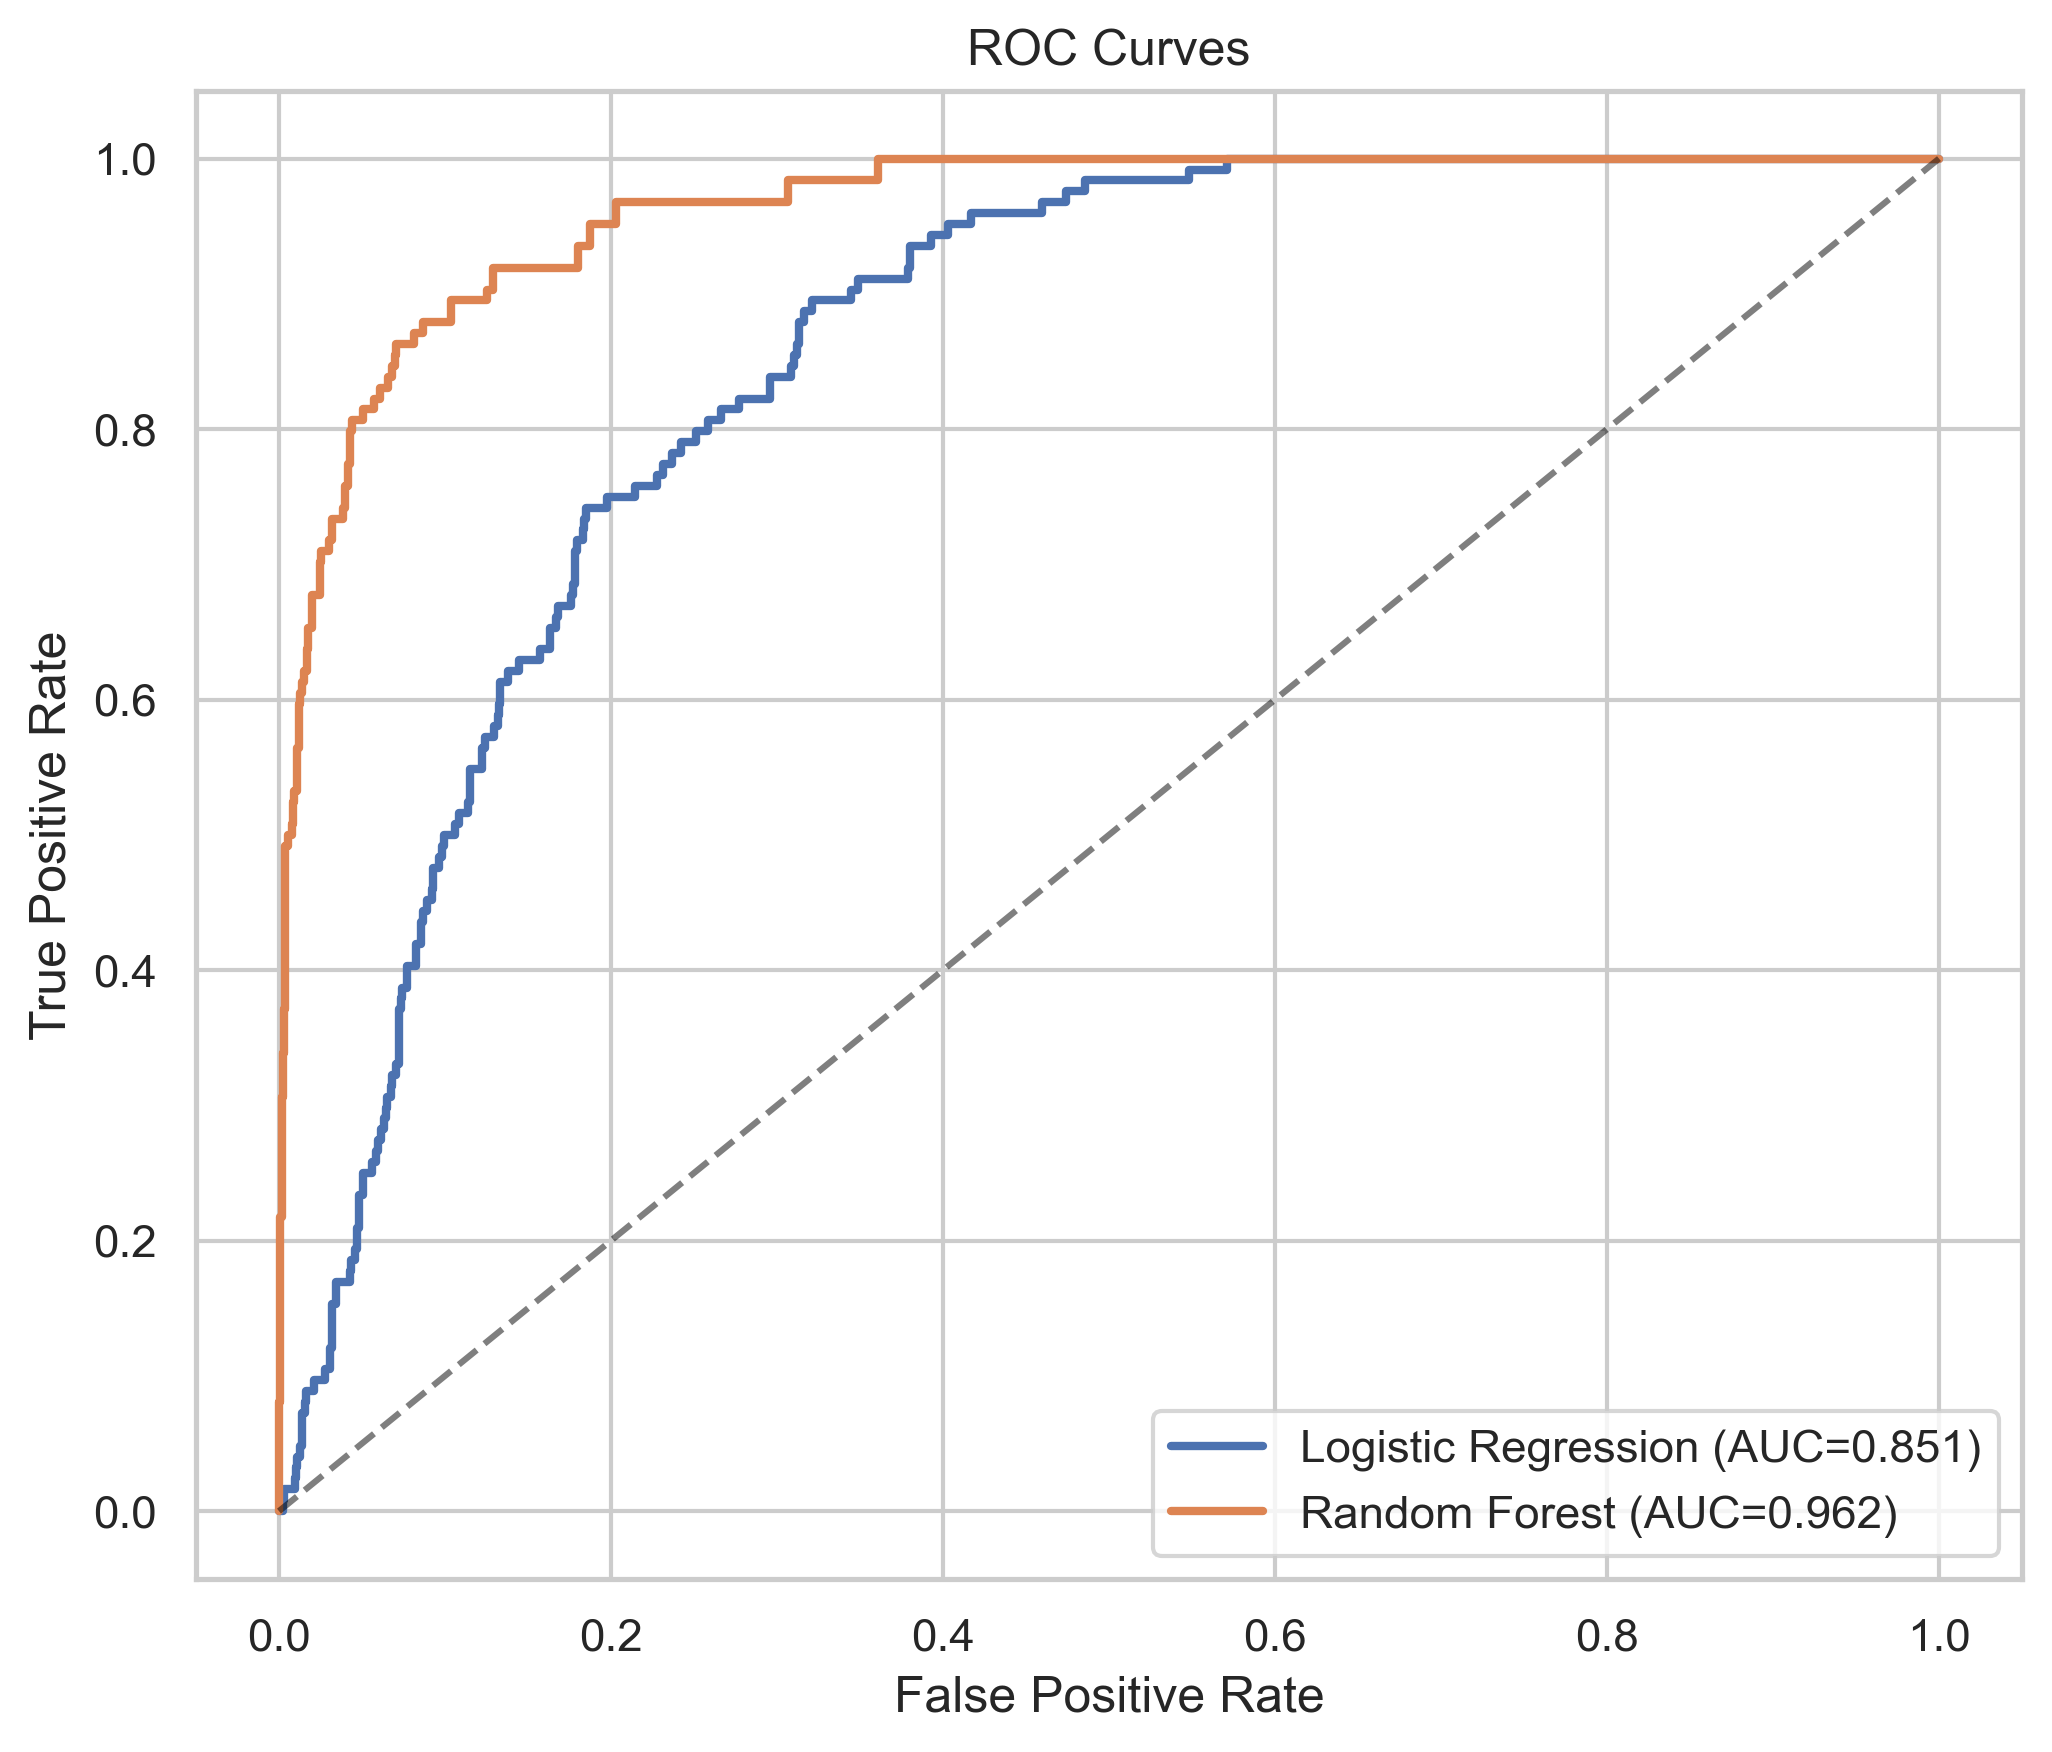

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})", linewidth=2)
plt.plot([0,1],[0,1],'k--', alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_curves.png")
plt.show()

## SECTION 14 — SHAP Interpretability

If SHAP is installed and available, compute SHAP values for the Random Forest and create a summary plot.
If SHAP is not installed, this cell will print a helpful message.


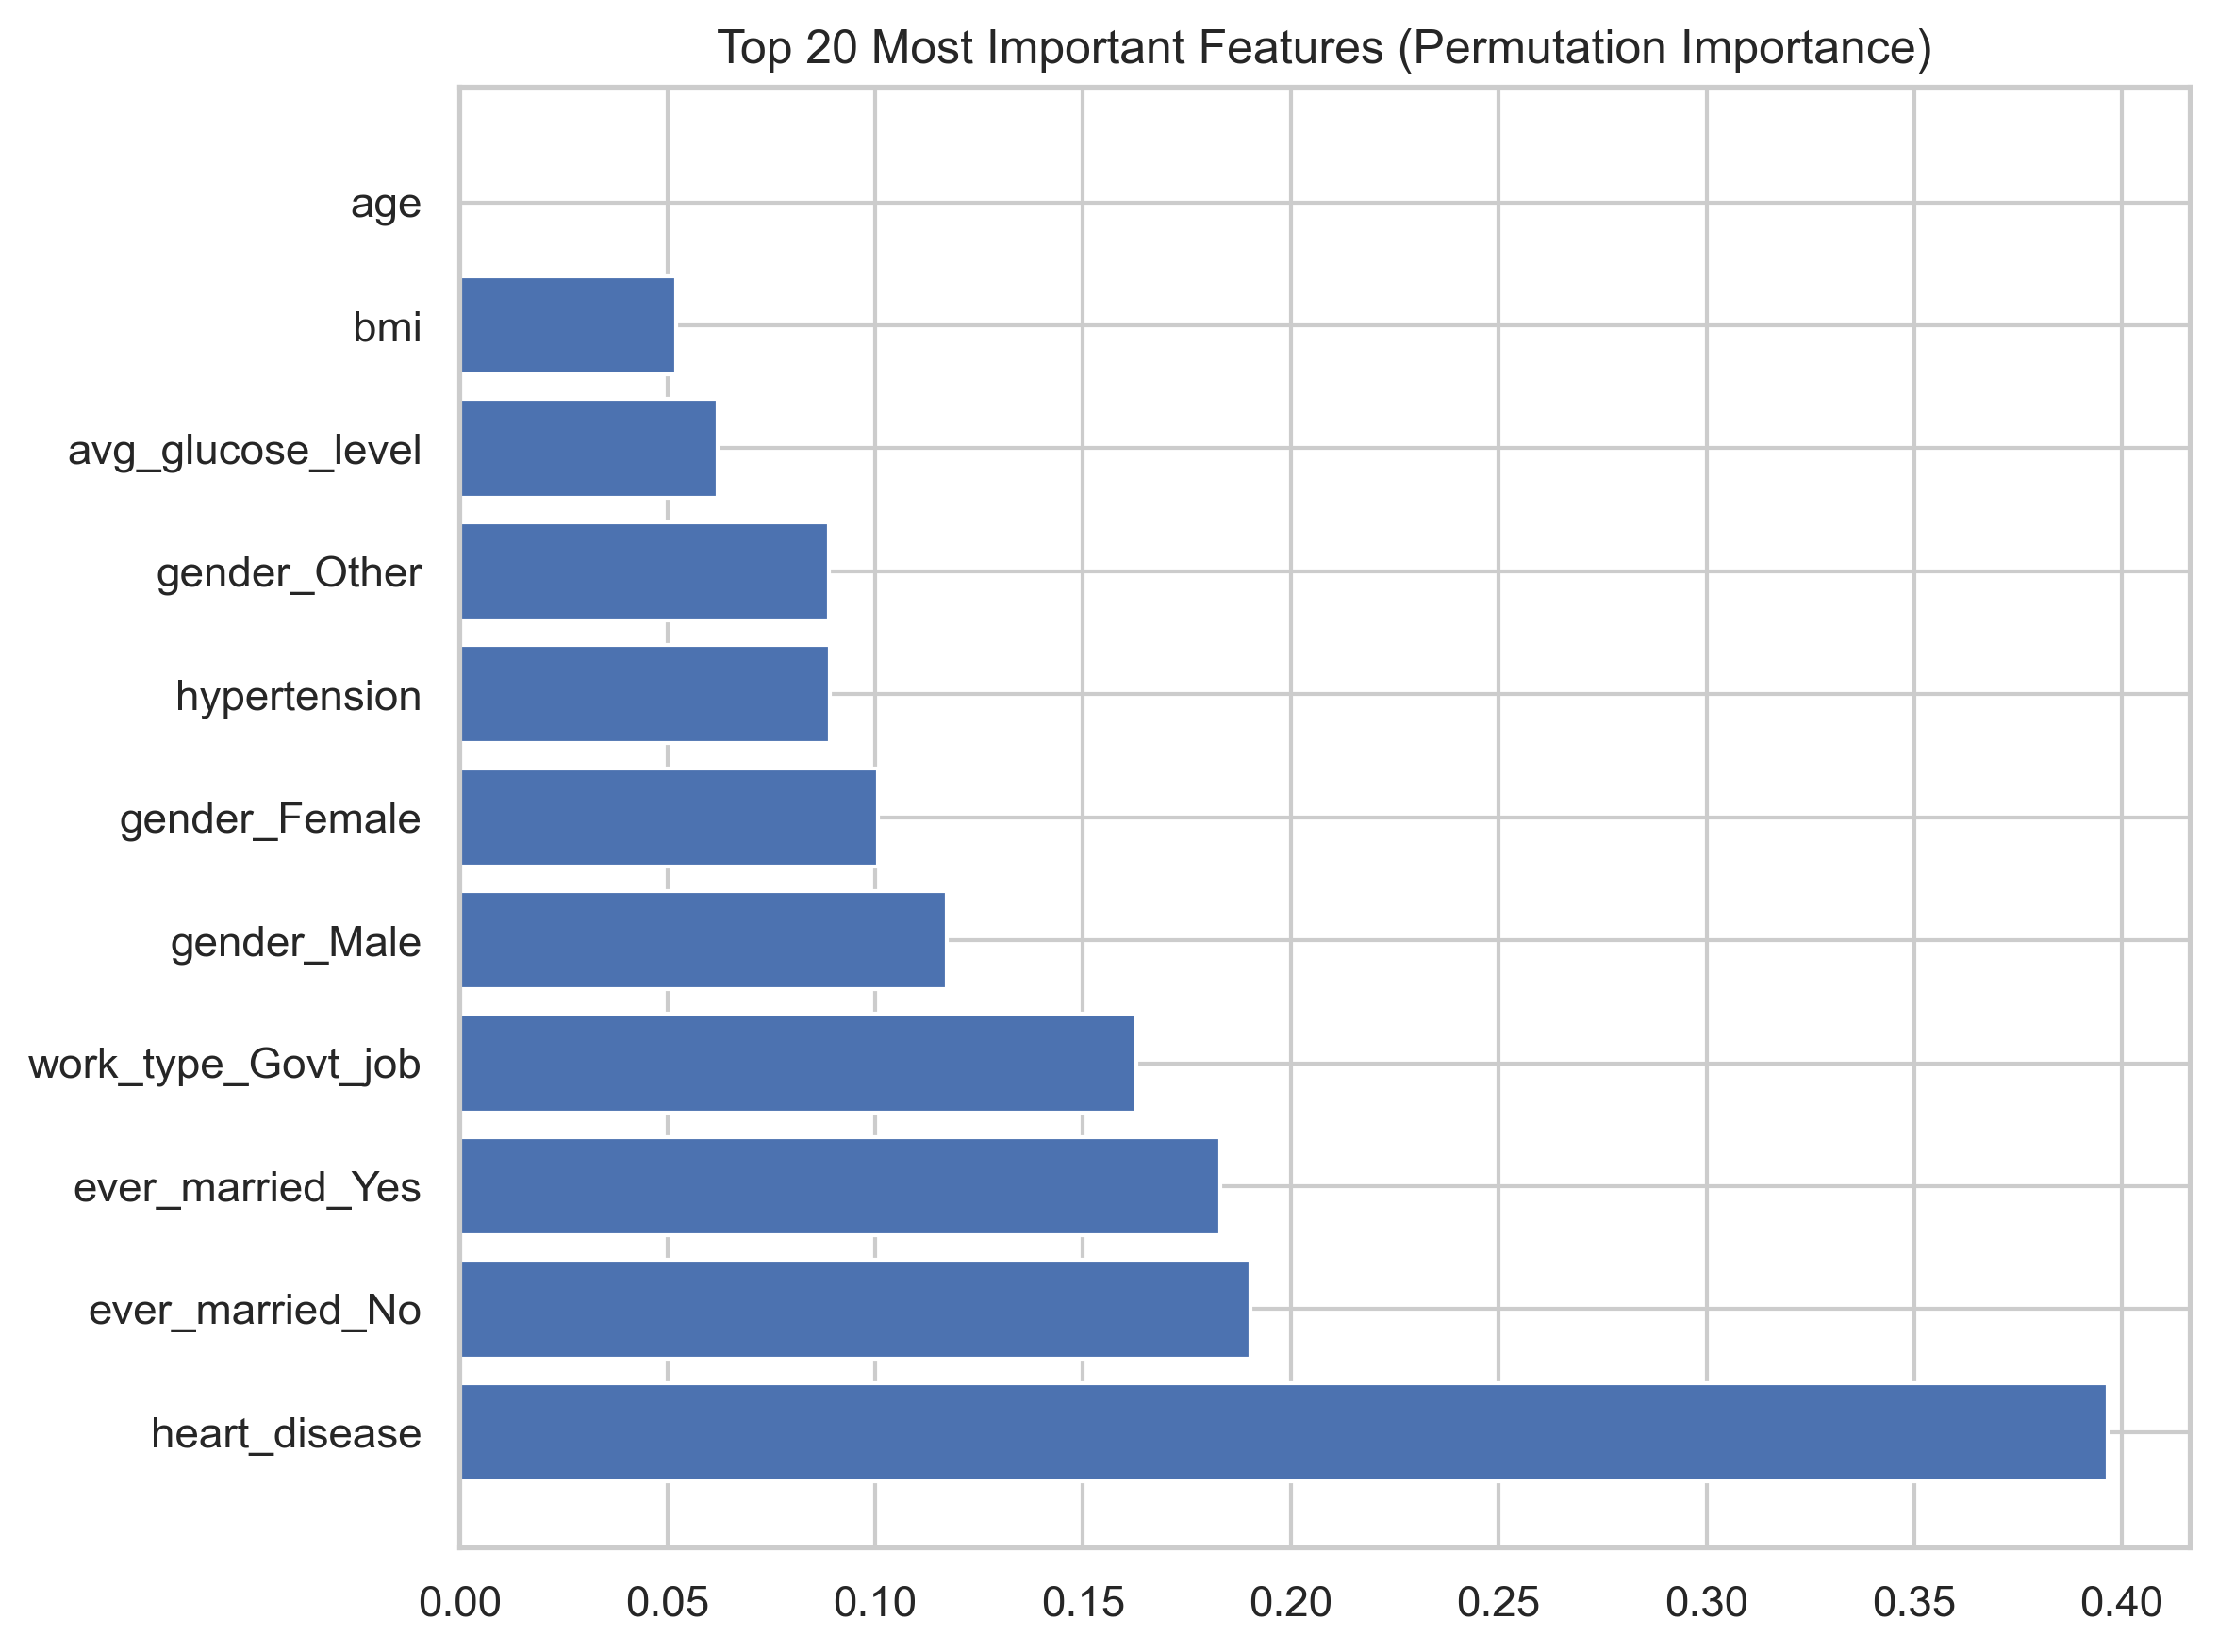

In [27]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

num_features = numeric_cols
cat_features = preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(categorical_cols)
feature_names = list(num_features) + list(cat_features)

sorted_idx = result.importances_mean.argsort()[::-1]

plt.figure(figsize=(8,6))
plt.barh(np.array(feature_names)[sorted_idx][:20], result.importances_mean[sorted_idx][:20], color=DEFAULT_PALETTE[0])
plt.title("Top 20 Most Important Features (Permutation Importance)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/permutation_importance_rf.png")
plt.show()

## SECTION 15 — Model Comparison

Summary of key metrics for both models. The results table is saved as CSV for easy inclusion in the report.


In [28]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "Cohen Kappa": [
        cohen_kappa_score(y_test, y_pred_lr),
        cohen_kappa_score(y_test, y_pred_rf)
    ]
})

results.to_csv(f"{FIG_DIR}/model_comparison_results.csv", index=False)
results

,Model,Accuracy,F1 Score,AUC,Cohen Kappa
0,Logistic Regression,0.951468,0.000000,0.851020,0.000000
1,Random Forest,0.938552,0.562674,0.962447,0.533002
